
## Classification d'image multiclasses

## Architecture : CNN

## Dataset : MNIST

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [3]:
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


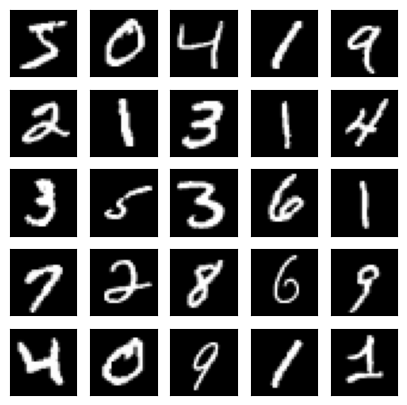

In [6]:
plt.figure(figsize=(5,5))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i],cmap='gray')
plt.show()

Normalisation des données

In [7]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Conv2D, Dense, Input,Flatten,Dropout
from tensorflow.keras import Sequential

train_images, test_images = train_images/255.0,test_images/255.0
train_images, val_images,train_labels,val_labels = train_test_split(train_images,train_labels,random_state=420,test_size=0.2)
train_images.shape

(48000, 28, 28)

In [8]:
hidden1     = 10
hidden2     = 100

model = keras.Sequential([
    keras.layers.Input((28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense( hidden1, activation='relu'),
    keras.layers.Dense( 10,      activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │           7,850 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             110 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,960 (31.09 KB)

 Trainable params: 7,960 (31.09 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer='adam',loss=tf.losses.SparseCategoricalCrossentropy(),metrics=['acc'])
model.fit(train_images,train_labels,batch_size=32,epochs=10,validation_data=(val_images,val_labels))

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.7523 - loss: 0.8651 - val_acc: 0.9038 - val_loss: 0.3378
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.9101 - loss: 0.3146 - val_acc: 0.9199 - val_loss: 0.2926
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.9203 - loss: 0.2780 - val_acc: 0.9225 - val_loss: 0.2812
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.9259 - loss: 0.2611 - val_acc: 0.9240 - val_loss: 0.2770
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.9271 - loss: 0.2503 - val_acc: 0.9240 - val_loss: 0.2721
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.9319 - loss: 0.2411 - val_acc: 0.9264 - val_loss: 0.2652
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.9345 - loss: 0.2314 - val_acc: 0.9270 - val_loss: 0.2646
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.9363 - loss: 0.2300 - val_acc: 0.9265 - val_loss: 0.2602
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━

In [10]:
##On va evaluer le model
test_labels_pred = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [11]:
model.evaluate(test_images,test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - acc: 0.9225 - loss: 0.2708


[0.24311304092407227, 0.9304999709129333]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


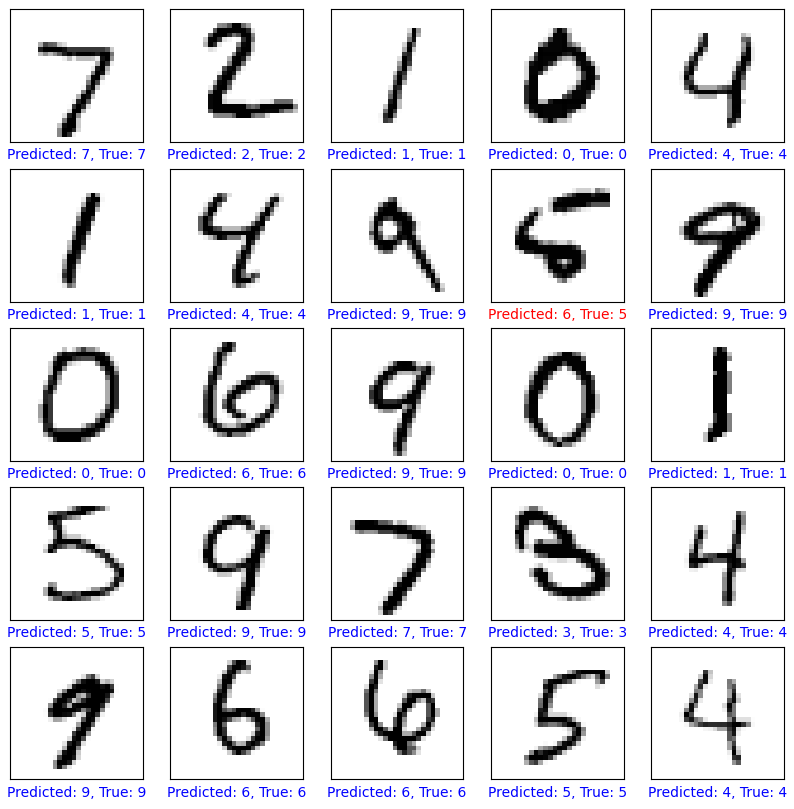

In [12]:
import numpy as np

# Effectuer les prédictions sur l'ensemble de test
predictions = model.predict(test_images)

# Afficher quelques exemples avec leurs prédictions
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(test_images[i], cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions[i])
    true_label = test_labels[i]
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'
    plt.xlabel(f'Predicted: {predicted_label}, True: {true_label}', color=color)
plt.show()


## ce modele de CNN donne de bien meilleur resultats pour ce set de donnée

In [13]:
model = Sequential()
model.add(Input((28,28,1)))
model.add(Conv2D(16,kernel_size=(3,3),activation="relu",padding="same"))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 28, 28, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │         401,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 401,930 (1.53 MB)

 Trainable params: 401,930 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(optimizer='adam',loss=tf.losses.SparseCategoricalCrossentropy(),metrics=['acc'])
model.fit(train_images,train_labels,batch_size=32,epochs=10,validation_data=(val_images,val_labels))

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - acc: 0.8756 - loss: 0.4179 - val_acc: 0.9720 - val_loss: 0.0960
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - acc: 0.9738 - loss: 0.0852 - val_acc: 0.9741 - val_loss: 0.0804
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - acc: 0.9824 - loss: 0.0576 - val_acc: 0.9783 - val_loss: 0.0709
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - acc: 0.9867 - loss: 0.0424 - val_acc: 0.9780 - val_loss: 0.0819
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - acc: 0.9883 - loss: 0.0345 - val_acc: 0.9805 - val_loss: 0.0708
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - acc: 0.9908 - loss: 0.0282 - val_acc: 0.9805 - val_loss: 0.0709
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - acc: 0.9920 - loss: 0.0249 - val_acc: 0.9813 - val_loss: 0.0711
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - acc: 0.9942 - loss: 0.0182 - val_acc: 0.9811 - val_loss: 0.0730
Epoch 9/10
1500/1500 ━━━━━━━━━

In [15]:
##On va evaluer le model
test_labels_pred = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [16]:
model.evaluate(test_images,test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9776 - loss: 0.0866


[0.07004085183143616, 0.9811000227928162]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


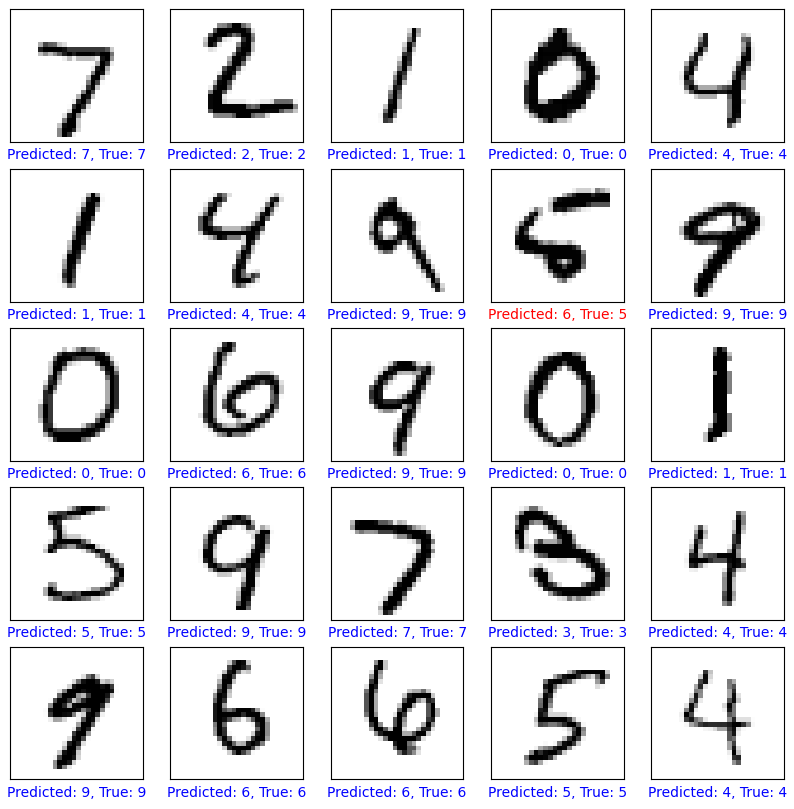

In [17]:
import numpy as np

# Effectuer les prédictions sur l'ensemble de test
predictions = model.predict(test_images)

# Afficher quelques exemples avec leurs prédictions
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(test_images[i], cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions[i])
    true_label = test_labels[i]
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'
    plt.xlabel(f'Predicted: {predicted_label}, True: {true_label}', color=color)
plt.show()